In [1]:
import json

# Load the JSON data from file
with open('/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep/qor_0.90/checkpoint_hour_8760.json', 'r') as file:
    data = json.load(file)

# Extract the deployments list
deployments = data['deployments']

# Total hours (assuming 168 as per 'last_hour')
total_hours = 8760

# Initialize dictionaries for calculations
machine_types = ['0', '1', '2']
total_active_counts = {key: 0 for key in machine_types}
active_hours_count = {key: 0 for key in machine_types}

# Process each deployment entry
for deployment in deployments:
    machines_per_type = deployment['machines_per_type']
    for typ in machine_types:
        count = machines_per_type[typ]
        total_active_counts[typ] += count
        if count > 0:
            active_hours_count[typ] += 1

# Additional: Total machine-hours across all types
total_all_machines = sum(total_active_counts.values())

# Original calculations
time_based_utilization_pct = {}
average_active_machines = {}
for typ in machine_types:
    time_based_utilization_pct[typ] = (active_hours_count[typ] / total_hours) * 100
    average_active_machines[typ] = total_active_counts[typ] / total_hours

# New calculation from your snippet: Overall percentage of total machine-hours per type
overall_utilization_pct = {}
for typ in machine_types:
    if total_all_machines > 0:
        overall_utilization_pct[f'Type {typ}'] = (total_active_counts[typ] / total_all_machines) * 100
    else:
        overall_utilization_pct[f'Type {typ}'] = 0.0

# Output the results
print("Machine Type Metrics:")
print("=" * 80)
for typ in machine_types:
    print(f"Type {typ}:")
    print(f"  - Time-Based Utilization (%): {time_based_utilization_pct[typ]:.2f} (hours active / total hours)")
    print(f"  - Average Active Machines: {average_active_machines[typ]:.2f} (avg machines per hour)")
    print(f"  - Overall Utilization (%): {overall_utilization_pct[f'Type {typ}']:.2f} (share of total machine-hours)")
    print()

Machine Type Metrics:
Type 0:
  - Time-Based Utilization (%): 94.27 (hours active / total hours)
  - Average Active Machines: 5.92 (avg machines per hour)
  - Overall Utilization (%): 37.94 (share of total machine-hours)

Type 1:
  - Time-Based Utilization (%): 99.60 (hours active / total hours)
  - Average Active Machines: 5.39 (avg machines per hour)
  - Overall Utilization (%): 34.57 (share of total machine-hours)

Type 2:
  - Time-Based Utilization (%): 93.11 (hours active / total hours)
  - Average Active Machines: 4.29 (avg machines per hour)
  - Overall Utilization (%): 27.49 (share of total machine-hours)



In [2]:
import json
import os
import pandas as pd

# Base directory
base_dir = '/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep/'

# Generate qor values from 0.10 to 0.99 in 0.01 steps
qor_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.9, 0.99]

# Machine types and total hours
machine_types = ['0', '1', '2']
total_hours = 8760

# Dictionary to hold results
results = {}

# Cell 2: Data Processing Loop
for qor in qor_values:
    dir_name = f'qor_{qor:.2f}'
    file_path = os.path.join(base_dir, dir_name, 'checkpoint_hour_8760.json')
    
    if not os.path.exists(file_path):
        print(f"Skipping {dir_name}: File not found at {file_path}")
        continue
    
    # Load the JSON data from file
    with open(file_path, 'r') as file:
        data = json.load(file)
    
    # Extract the deployments list
    deployments = data['deployments']
    
    # Initialize dictionaries for calculations
    total_active_counts = {key: 0 for key in machine_types}
    active_hours_count = {key: 0 for key in machine_types}
    
    # Process each deployment entry
    for deployment in deployments:
        machines_per_type = deployment['machines_per_type']
        for typ in machine_types:
            count = machines_per_type[typ]
            total_active_counts[typ] += count
            if count > 0:
                active_hours_count[typ] += 1
    
    # Additional: Total machine-hours across all types
    total_all_machines = sum(total_active_counts.values())
    
    # Calculations
    time_based_utilization_pct = {}
    average_active_machines = {}
    overall_utilization_pct = {}
    for typ in machine_types:
        time_based_utilization_pct[typ] = (active_hours_count[typ] / total_hours) * 100
        average_active_machines[typ] = total_active_counts[typ] / total_hours
        overall_utilization_pct[typ] = (total_active_counts[typ] / total_all_machines) * 100 if total_all_machines > 0 else 0.0
    
    # Store results
    results[qor] = {
        'time_based': time_based_utilization_pct,
        'avg_active': average_active_machines,
        'overall': overall_utilization_pct
    }

# Cell 3: Create DataFrame
# Collect data for DataFrame
data_rows = []
for qor in sorted(results.keys()):
    for typ in machine_types:
        data_rows.append({
            'QOR': qor,
            'Type': typ,
            'Time-Based Utilization (%)': round(results[qor]['time_based'][typ], 2),
            'Average Active Machines': round(results[qor]['avg_active'][typ], 2),
            'Overall Utilization (%)': round(results[qor]['overall'][typ], 2)
        })

# Create DataFrame
df = pd.DataFrame(data_rows)

# Display the DataFrame
print("QOR Sweep Results:")
display(df)  # Better than print in Jupyter for tables





QOR Sweep Results:


,QOR,Type,Time-Based Utilization (%),Average Active Machines,Overall Utilization (%)
0,0.10,0,99.79,2.56,19.53
1,0.10,1,99.54,10.54,80.39
2,0.10,2,1.06,0.01,0.08
3,0.20,0,96.13,3.06,22.66
4,0.20,1,99.53,9.86,73.07
5,0.20,2,36.60,0.58,4.27
6,0.30,0,93.26,3.11,23.27
7,0.30,1,99.53,8.91,66.77
8,0.30,2,68.33,1.33,9.96
9,0.40,0,94.77,3.69,26.79


In [3]:
# Cell 4: Pivoted Table for Better Structure
# Create a pivoted DataFrame with QOR as index and multi-level columns
pivot_df = df.pivot(index='QOR', columns='Type')

# Rename columns for clarity
pivot_df.columns = pd.MultiIndex.from_tuples([
    (f'Time-Based Utilization (Type {typ})', ' (%)') for typ in machine_types
] + [
    (f'Average Active Machines (Type {typ})', '') for typ in machine_types
] + [
    (f'Overall Utilization (Type {typ})', ' (%)') for typ in machine_types
])

print("Structured QOR Sweep Results (Pivoted Table):")
display(pivot_df)

Structured QOR Sweep Results (Pivoted Table):


,Time-Based Utilization (Type 0),Time-Based Utilization (Type 1),Time-Based Utilization (Type 2),Average Active Machines (Type 0),Average Active Machines (Type 1),Average Active Machines (Type 2),Overall Utilization (Type 0),Overall Utilization (Type 1),Overall Utilization (Type 2)
,(%),(%),(%),,,,(%),(%),(%)
QOR,,,,,,,,,
0.10,99.79,99.54,1.06,2.56,10.54,0.01,19.53,80.39,0.08
0.20,96.13,99.53,36.60,3.06,9.86,0.58,22.66,73.07,4.27
0.30,93.26,99.53,68.33,3.11,8.91,1.33,23.27,66.77,9.96
0.40,94.77,99.50,81.64,3.69,8.29,1.80,26.79,60.16,13.05
0.50,95.91,99.44,87.41,4.14,7.69,2.30,29.27,54.45,16.27
0.60,96.30,99.45,90.09,4.56,7.07,2.82,31.59,48.92,19.49
0.70,96.36,99.51,91.60,4.97,6.49,3.32,33.62,43.91,22.47
0.80,93.93,99.57,92.60,5.40,5.86,3.84,35.79,38.78,25.42


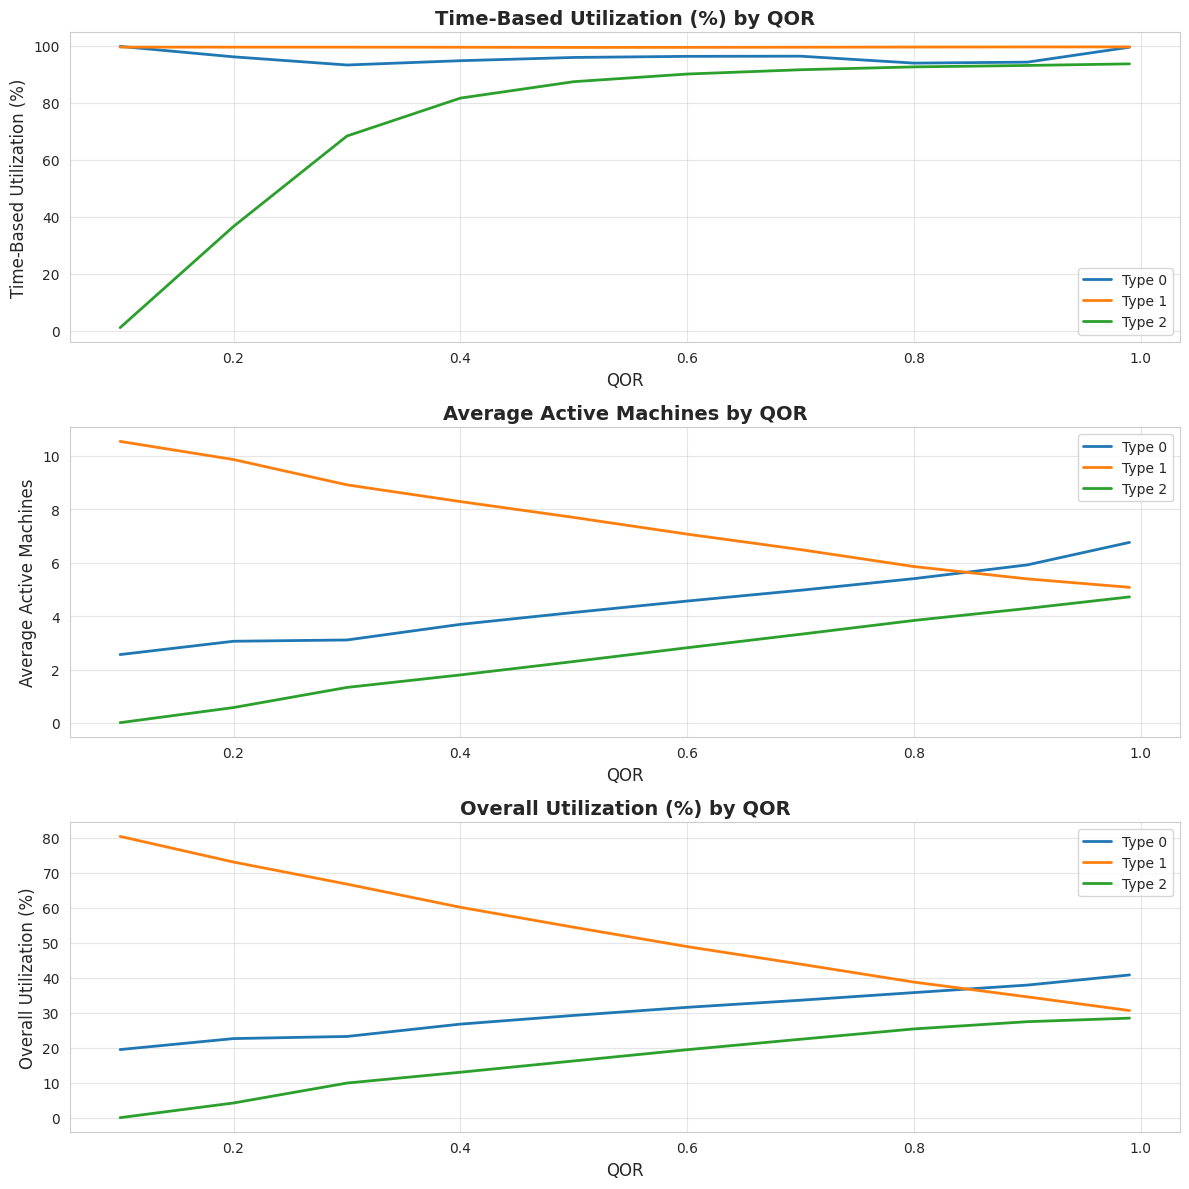

In [4]:
# Cell: Line Plot for Utilizations vs. QOR
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
metrics = ['time_based', 'avg_active', 'overall']
y_labels = ['Time-Based Utilization (%)', 'Average Active Machines', 'Overall Utilization (%)']

for i, (metric, ylabel) in enumerate(zip(metrics, y_labels)):
    ax = axes[i]
    for typ in machine_types:
        # Extract data
        x_vals = sorted(results.keys())
        y_vals = [results[qor][metric][typ] for qor in x_vals]
        ax.plot(x_vals, y_vals, label=f'Type {typ}', linewidth=2)
    ax.set_xlabel('QOR', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'{ylabel} by QOR', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('utilization_trends_vs_qor.pdf', dpi=300, bbox_inches='tight')  # Save for journal
plt.show()

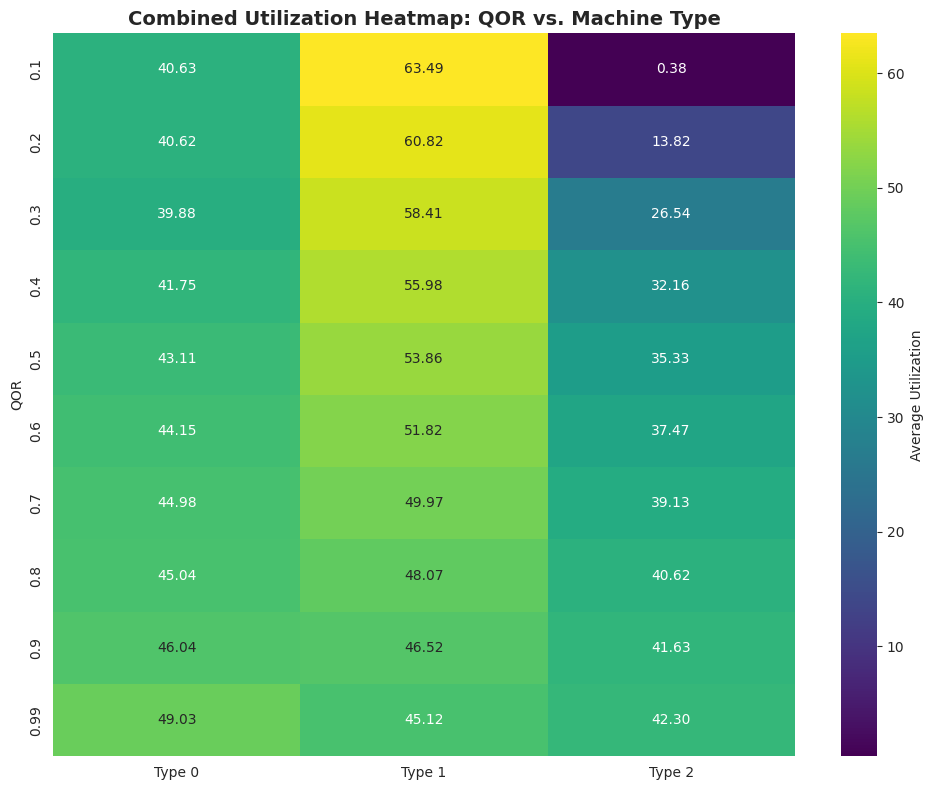

In [5]:
# Cell: Heatmap for Utilizations
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for heatmap
heatmap_data = []
for qor in sorted(results.keys()):
    row = [qor]
    for typ in machine_types:
        # Combine metrics for each type (e.g., average time-based + avg active + overall)
        avg_metric = (results[qor]['time_based'][typ] + results[qor]['avg_active'][typ] + results[qor]['overall'][typ]) / 3
        row.append(avg_metric)
    heatmap_data.append(row)

df_heatmap = pd.DataFrame(heatmap_data, columns=['QOR'] + [f'Type {typ}' for typ in machine_types])
df_heatmap.set_index('QOR', inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df_heatmap, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'Average Utilization'})
plt.title('Combined Utilization Heatmap: QOR vs. Machine Type', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('utilization_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

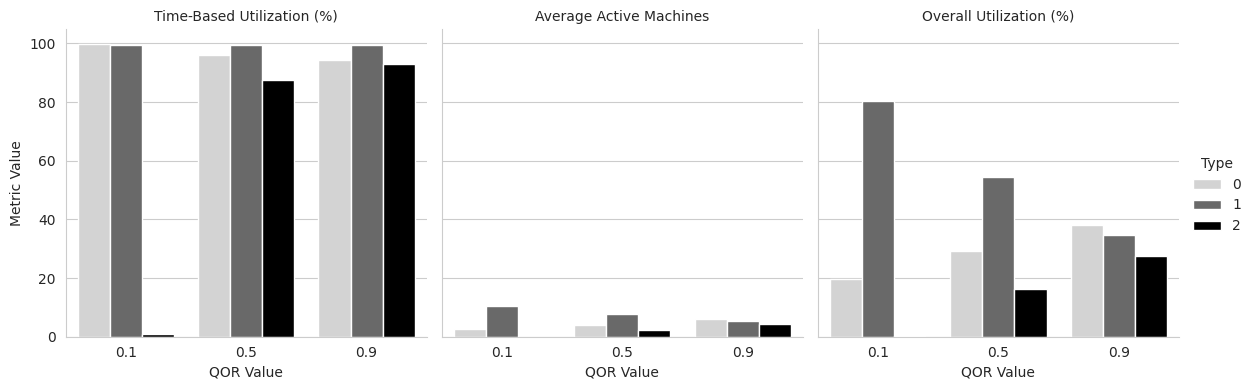

In [6]:
# Filter df for select QORs
select_qors = [0.10, 0.50, 0.90]
filtered_df = df[df['QOR'].isin(select_qors)]

# Melt for Seaborn
melted_df = filtered_df.melt(id_vars=['QOR', 'Type'], value_vars=['Time-Based Utilization (%)', 'Average Active Machines', 'Overall Utilization (%)'], 
                             var_name='Metric', value_name='Value')

g = sns.catplot(data=melted_df, kind='bar', x='QOR', y='Value', hue='Type', col='Metric', 
                palette=['lightgray', 'dimgray', 'black'], height=4, aspect=1)
g.set_axis_labels('QOR Value', 'Metric Value')
g.set_titles(col_template='{col_name}')
plt.savefig('utilization_comparison.pdf', format='pdf', dpi=300)
plt.show()

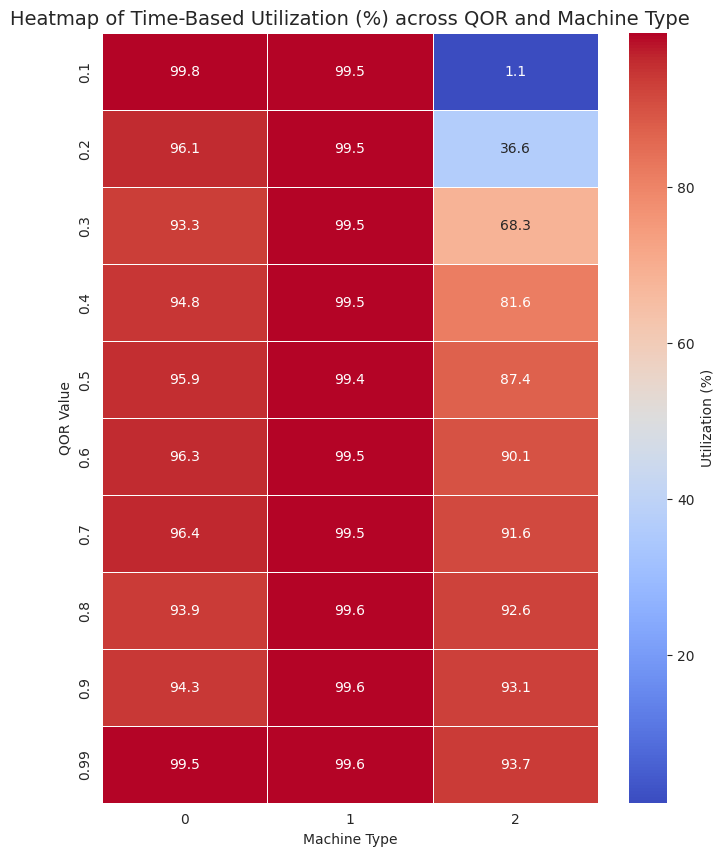

In [7]:
# Pivot for Time-Based Utilization as example
heatmap_df = df[df['Type'].isin(machine_types)].pivot(index='QOR', columns='Type', values='Time-Based Utilization (%)')

plt.figure(figsize=(8, 10))  # Tall for QOR range
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='coolwarm', cbar_kws={'label': 'Utilization (%)'}, linewidths=0.5)
plt.title('Heatmap of Time-Based Utilization (%) across QOR and Machine Type', fontsize=14)
plt.ylabel('QOR Value')
plt.xlabel('Machine Type')
plt.savefig('utilization_heatmap.pdf', format='pdf', dpi=300)
plt.show()

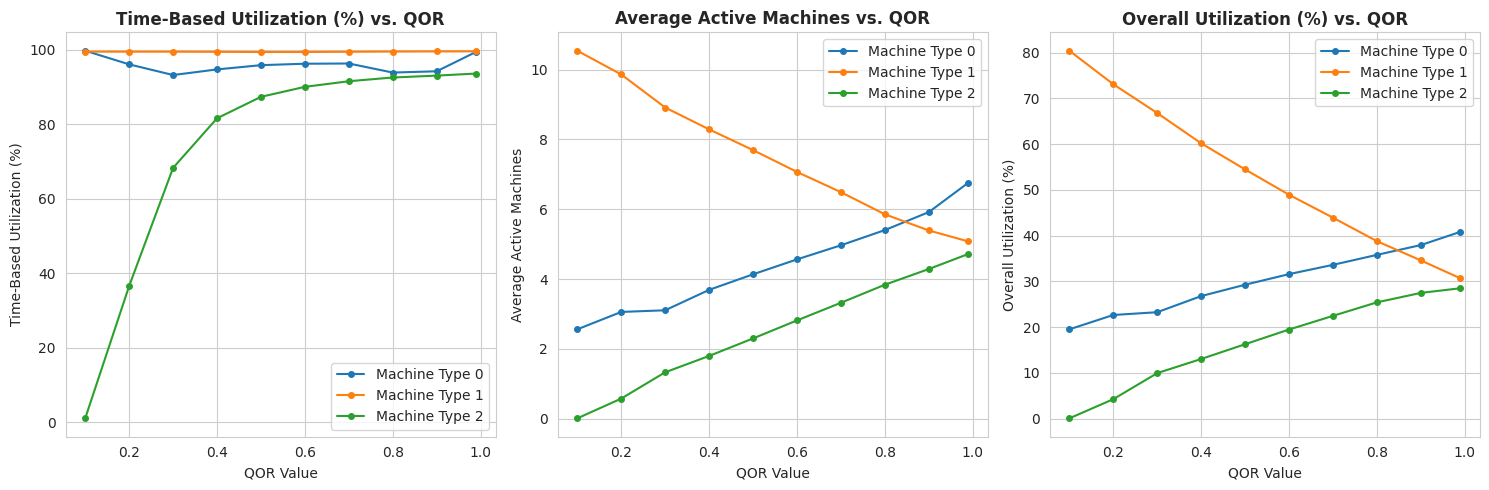

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")  # Professional, journal-like
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 3-panel for single-row subplots

metrics = ['time_based', 'avg_active', 'overall']
metric_labels = ['Time-Based Utilization (%)', 'Average Active Machines', 'Overall Utilization (%)']
qor_keys = sorted(results.keys())

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    for typ in machine_types:
        data = [results[qor][metric][typ] for qor in qor_keys]
        axes[i].plot(qor_keys, data, marker='o', markersize=4, label=f'Machine Type {typ}')
    axes[i].set_title(f'{label} vs. QOR', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('QOR Value')
    axes[i].set_ylabel(label)
    axes[i].legend(loc='best')
    axes[i].tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.savefig('utilization_trends.pdf', format='pdf', dpi=300, bbox_inches='tight')  # Export to vector
plt.show()

## Correlation